
Benchmarking MFIM (Neel Initial State, N=3000)...


Processing Time: 100%|█████████████████████████████████████████████████████████████████| 30/30 [04:27<00:00,  8.92s/it]



Benchmarking TFIM (Neel Initial State, N=3000)...


Processing Time: 100%|█████████████████████████████████████████████████████████████████| 30/30 [04:32<00:00,  9.08s/it]



Benchmarking PXP (Neel Initial State, N=3000)...


Processing Time: 100%|█████████████████████████████████████████████████████████████████| 30/30 [04:32<00:00,  9.09s/it]



Benchmarking MBL (Neel Initial State, N=3000)...


Processing Time: 100%|█████████████████████████████████████████████████████████████████| 30/30 [04:37<00:00,  9.24s/it]



[Success] 原始数据已安全保存至: E:\Quantum_Scar_Project\classical mutual information\数据集\benchmark_shadow_neel_data.pkl


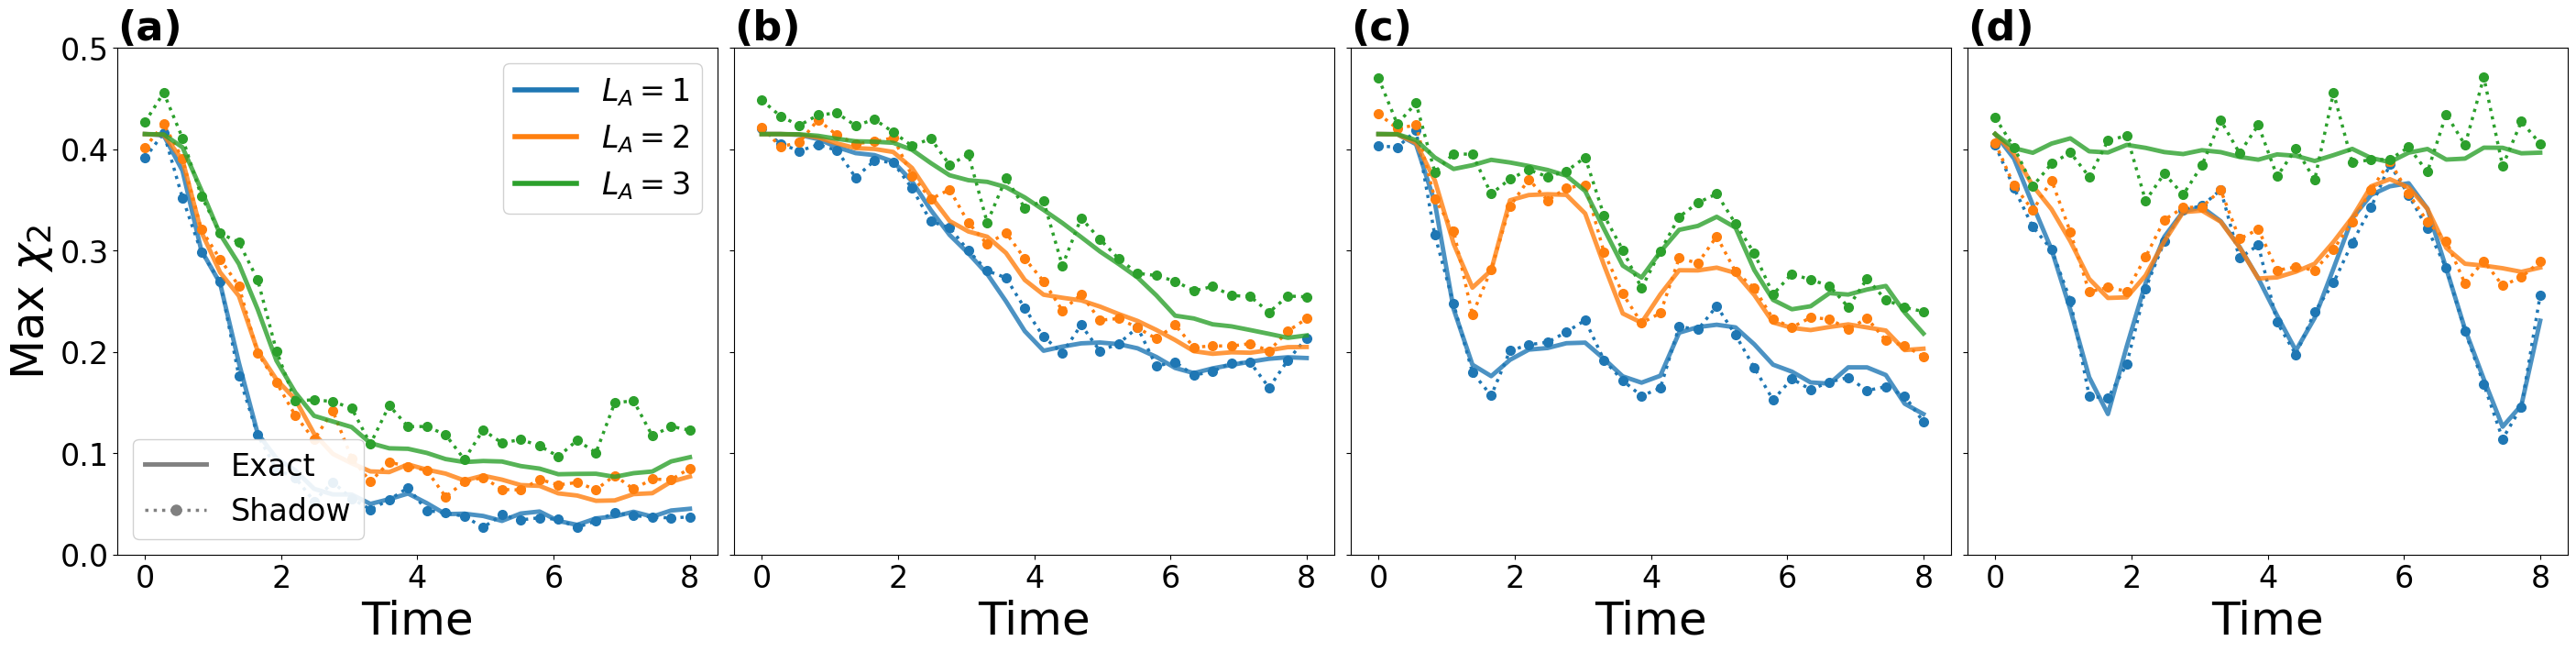

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import itertools
import os
import pickle
import matplotlib.lines as mlines

warnings.filterwarnings("ignore")

# 1. 精确值计算工具

def get_exact_reduced_rho(psi, L, target_sites):
    psi_tensor = psi.reshape([2] * L)
    axes_to_keep = list(target_sites)
    axes_to_trace = [i for i in range(L) if i not in target_sites]
    # 将保留的格点挪到张量前部
    psi_tensor = np.moveaxis(psi_tensor, axes_to_keep, range(len(axes_to_keep)))
    dim_keep = 2 ** len(target_sites)
    psi_mat = psi_tensor.reshape(dim_keep, -1)
    return np.dot(psi_mat, psi_mat.conj().T)

def get_exact_chi_H2(rho0, rho1):
    P0 = np.real(np.trace(np.dot(rho0, rho0)))
    P1 = np.real(np.trace(np.dot(rho1, rho1)))
    rho_mix = 0.5 * (rho0 + rho1)
    P_mix = np.real(np.trace(np.dot(rho_mix, rho_mix)))
    H2_0 = np.log2(2.0 / (1.0 + P0))
    H2_1 = np.log2(2.0 / (1.0 + P1))
    H2_mix = np.log2(2.0 / (1.0 + P_mix))
    return max(0.0, H2_mix - 0.5 * (H2_0 + H2_1))

# 2. 经典阴影核心函数 (U-Statistics & Median of Means)

U_rot = {
    0: np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2),   
    1: np.array([[1, -1j],[1, 1j]], dtype=complex) / np.sqrt(2), 
    2: np.eye(2, dtype=complex)                                   
}

def generate_classical_shadows_fast(psi_full, L, num_snapshots):
    shadow_data_bases = np.zeros((num_snapshots, L), dtype=int)
    shadow_data_outcomes = np.zeros((num_snapshots, L), dtype=int)
    for k in range(num_snapshots):
        bases = np.random.randint(0, 3, size=L)
        psi_tensor = psi_full.reshape([2] * L)
        for i, b in enumerate(bases):
            psi_tensor = np.tensordot(U_rot[b], psi_tensor, axes=([1], [i]))
            psi_tensor = np.moveaxis(psi_tensor, 0, i)
        psi_rotated = psi_tensor.flatten()
        probs = np.abs(psi_rotated)**2
        probs /= np.sum(probs) 
        outcome_int = np.random.choice(len(probs), p=probs)
        outcomes = [(outcome_int >> (L - 1 - i)) & 1 for i in range(L)]
        shadow_data_bases[k] = bases
        shadow_data_outcomes[k] = outcomes
    return shadow_data_bases, shadow_data_outcomes

def precompute_K_site_all(bA, oA, bB, oB, K, N, L):
    bA_r, oA_r = bA.reshape(K, N, L), oA.reshape(K, N, L)
    bB_r, oB_r = bB.reshape(K, N, L), oB.reshape(K, N, L)
    match_b = bA_r[:, :, None, :] == bB_r[:, None, :, :]
    match_o = oA_r[:, :, None, :] == oB_r[:, None, :, :]
    return np.where(match_b, np.where(match_o, 5.0, -4.0), 0.5)

def get_chi_H2_MoM_fast(K_site_00, K_site_11, K_site_01, target_sites, K, N):
    K_tot_00 = np.prod(K_site_00[:, :, :, target_sites], axis=-1)
    np.einsum('kii->ki', K_tot_00)[...] = 0.0
    P0_robust = np.median(np.sum(K_tot_00, axis=(1, 2)) / (N * (N - 1)))
    K_tot_11 = np.prod(K_site_11[:, :, :, target_sites], axis=-1)
    np.einsum('kii->ki', K_tot_11)[...] = 0.0
    P1_robust = np.median(np.sum(K_tot_11, axis=(1, 2)) / (N * (N - 1)))
    K_tot_01 = np.prod(K_site_01[:, :, :, target_sites], axis=-1)
    O01_robust = np.median(np.mean(K_tot_01, axis=(1, 2)))
    P_mix = 0.25 * P0_robust + 0.25 * P1_robust + 0.5 * O01_robust
    P0_c, P1_c, P_mix_c = np.clip(P0_robust, 1e-10, 1.0), np.clip(P1_robust, 1e-10, 1.0), np.clip(P_mix, 1e-10, 1.0)
    return max(0.0, np.log2(2.0/(1.0+P_mix_c)) - 0.5*(np.log2(2.0/(1.0+P0_c)) + np.log2(2.0/(1.0+P1_c))))

# 3. 哈密顿量构建类

class QuantumChain:
    def __init__(self, L, model_type, **kwargs):
        self.L = L; self.dim = 2**L; self.pxp_basis = None; self.pxp_map = None
        if model_type == 'MFIM':
            self.H = self._build_mfim(1.0, (np.sqrt(5)+5)/8, (np.sqrt(5)+1)/4)
        elif model_type == 'TFIM':
            self.H = self._build_tfim(1.0, 0.3)
        elif model_type == 'PXP':
            self.H, self.pxp_basis, self.pxp_map = self._build_pxp()
            self.dim_valid = len(self.pxp_basis)
        elif model_type == 'MBL':
            self.H = self._build_mbl_corrected(kwargs.get('W', 8.0))
            
    def _kron_list(self, matrices):
        res = matrices[0]
        for m in matrices[1:]: res = sp.kron(res, m)
        return res

    def _build_mfim(self, J, g, h):
        sx, sz, id2 = sp.csr_matrix([[0,1],[1,0]]), sp.csr_matrix([[1,0],[0,-1]]), sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim))
        for i in range(self.L): ops=[id2]*self.L; ops[i]=sx; H+=g*self._kron_list(ops)
        for i in range(1,self.L-1): ops=[id2]*self.L; ops[i]=sz; H+=h*self._kron_list(ops)
        for i in range(self.L-1): ops=[id2]*self.L; ops[i]=sz; ops[i+1]=sz; H+=J*self._kron_list(ops)
        return H

    def _build_tfim(self, J, h):
        sx, sz, id2 = sp.csr_matrix([[0,1],[1,0]]), sp.csr_matrix([[1,0],[0,-1]]), sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim), dtype=complex)
        for i in range(self.L): ops=[id2]*self.L; ops[i]=sx; H+=(-h)*self._kron_list(ops)
        for i in range(self.L-1): ops=[id2]*self.L; ops[i]=sz; ops[i+1]=sz; H+=(-J)*self._kron_list(ops)
        return H

    def _build_pxp(self):
        basis = [i for i in range(2**self.L) if (i&(i<<1))==0]
        basis = np.array(basis, dtype=np.int32); pxp_map = {s:i for i,s in enumerate(basis)}
        rows, cols, data = [], [], []
        for idx, state in enumerate(basis):
            for i in range(self.L):
                m_i, m_l, m_r = 1<<(self.L-1-i), (1<<(self.L-1-(i-1)) if i>0 else 0), (1<<(self.L-1-(i+1)) if i<self.L-1 else 0)
                if (state&m_l)==0 and (state&m_r)==0:
                    ns = state^m_i
                    if ns in pxp_map: rows.append(pxp_map[ns]); cols.append(idx); data.append(1.0)
        return sp.csr_matrix((data,(rows,cols)), shape=(len(basis), len(basis))), basis, pxp_map

    def _build_mbl_corrected(self, W):
        sx, sy, sz, id2 = sp.csr_matrix([[0,1],[1,0]]), sp.csr_matrix([[0,-1j],[1j,0]]), sp.csr_matrix([[1,0],[0,-1]]), sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim), dtype=complex)
        np.random.seed(42); fields = np.random.uniform(-W, W, self.L)
        for i in range(self.L-1):
            for op in [sx, sy, sz]: ops=[id2]*self.L; ops[i]=op; ops[i+1]=op; H+=0.25*self._kron_list(ops)
        for i in range(self.L): ops=[id2]*self.L; ops[i]=sz; H+=(fields[i]*0.5)*self._kron_list(ops)
        return H

# 4. 主程序

def benchmark_shadow_vs_exact(L=10, times=None, K_groups=15, N_per_group=200):
    num_snapshots = K_groups * N_per_group
    if times is None: times = np.linspace(0, 8, 30)
    sub_sizes = [1, 2, 3]
    models = ['MFIM', 'TFIM', 'PXP', 'MBL'] 
    
    center_site = L // 2
    neel_int = 0
    for i in range(0, L, 2): neel_int |= (1 << (L - 1 - i))
    
    mask_center = 1 << (L - 1 - center_site)
    if (neel_int & mask_center) > 0:
        pert_int = neel_int ^ mask_center
    else:
        pert_int = neel_int ^ (1 << (L - 1 - (center_site - 1)))

    results = {m: {size: {'exact': [], 'shadow': []} for size in sub_sizes} for m in models}

    for m_name in models:
        print(f"\nBenchmarking {m_name} (Neel Initial State, N={num_snapshots})...")
        sys = QuantumChain(L, m_name)
        
        if m_name == 'PXP':
            psi0, psi1 = np.zeros(sys.dim_valid, dtype=complex), np.zeros(sys.dim_valid, dtype=complex)
            psi0[sys.pxp_map[neel_int]] = 1.0; psi1[sys.pxp_map[pert_int]] = 1.0
        else:
            psi0, psi1 = np.zeros(sys.dim, dtype=complex), np.zeros(sys.dim, dtype=complex)
            psi0[neel_int] = 1.0; psi1[pert_int] = 1.0
            
        traj0 = expm_multiply(-1j * sys.H, psi0, start=times[0], stop=times[-1], num=len(times))
        traj1 = expm_multiply(-1j * sys.H, psi1, start=times[0], stop=times[-1], num=len(times))
        
        for t_idx in tqdm(range(len(times)), desc="Processing Time"):
            if m_name == 'PXP':
                p0_full, p1_full = np.zeros(2**L, dtype=complex), np.zeros(2**L, dtype=complex)
                p0_full[sys.pxp_basis], p1_full[sys.pxp_basis] = traj0[t_idx], traj1[t_idx]
            else:
                p0_full, p1_full = traj0[t_idx], traj1[t_idx]
                
            b0, o0 = generate_classical_shadows_fast(p0_full, L, num_snapshots)
            b1, o1 = generate_classical_shadows_fast(p1_full, L, num_snapshots)
            
            K00 = precompute_K_site_all(b0, o0, b0, o0, K_groups, N_per_group, L)
            K11 = precompute_K_site_all(b1, o1, b1, o1, K_groups, N_per_group, L)
            K01 = precompute_K_site_all(b0, o0, b1, o1, K_groups, N_per_group, L)
            
            for size in sub_sizes:
                vals_ex, vals_sh = [], []
                for st in itertools.combinations(range(L), size):
                    target = list(st)
                    rho0_ex = get_exact_reduced_rho(p0_full, L, target)
                    rho1_ex = get_exact_reduced_rho(p1_full, L, target)
                    vals_ex.append(get_exact_chi_H2(rho0_ex, rho1_ex))
                    vals_sh.append(get_chi_H2_MoM_fast(K00, K11, K01, target, K_groups, N_per_group))
                
                results[m_name][size]['exact'].append(np.max(vals_ex))
                results[m_name][size]['shadow'].append(np.max(vals_sh))
    return results

# 5. 执行与绘图 

if __name__ == "__main__":
    L, times = 10, np.linspace(0, 8.0, 30)
    K_gr, N_per = 15, 200 # 3000 shots total
    
    res = benchmark_shadow_vs_exact(L, times, K_gr, N_per)
    
    save_dir = r"E:\Quantum_Scar_Project\classical mutual information\数据集"
    os.makedirs(save_dir, exist_ok=True)
    
    data_path = os.path.join(save_dir, "benchmark_shadow_neel_data.pkl")
    with open(data_path, 'wb') as f:
        pickle.dump(res, f)
    print(f"\n[Success] 原始数据已安全保存至: {data_path}")
 
    fig, axes = plt.subplots(1, 4, figsize=(28, 7), constrained_layout=True)
    models = ['MFIM', 'TFIM', 'PXP', 'MBL']
    colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c'}

    ylim_top = (0, 0.50)
    top_titles = ['(a)', '(b)', '(c)', '(d)']

    for col, m_name in enumerate(models):
        for size in [1, 2, 3]:
            ex_v = np.array(res[m_name][size]['exact'])
            sh_v = np.array(res[m_name][size]['shadow'])
            
            axes[col].plot(times, ex_v, color=colors[size], ls='-', lw=3.5, alpha=0.8)
            axes[col].plot(times, sh_v, color=colors[size], ls=':', marker='o', ms=7, lw=2.5)

        axes[col].set_ylim(ylim_top)
        axes[col].set_title(top_titles[col], fontsize=32, loc='left', fontweight='bold')
        axes[col].tick_params(axis='both', which='major', labelsize=24)
        axes[col].set_xlabel("Time", fontsize=36)

        if col == 0:
            axes[col].set_ylabel(r"Max $\chi_2$", fontsize=36)
        else:
            axes[col].set_yticklabels([])

    ax0 = axes[0]
    
    legend_LA_elements = [
        mlines.Line2D([0], [0], color=colors[1], lw=4, label=r'$L_A = 1$'),
        mlines.Line2D([0], [0], color=colors[2], lw=4, label=r'$L_A = 2$'),
        mlines.Line2D([0], [0], color=colors[3], lw=4, label=r'$L_A = 3$')
    ]
    leg_LA = ax0.legend(handles=legend_LA_elements, fontsize=24, loc='upper right', framealpha=0.9)
    ax0.add_artist(leg_LA) 
    
    legend_Method_elements = [
        mlines.Line2D([0], [0], color='gray', ls='-', lw=3.5, label='Exact'),
        mlines.Line2D([0], [0], color='gray', ls=':', marker='o', ms=8, lw=2.5, label='Shadow')
    ]
    ax0.legend(handles=legend_Method_elements, fontsize=24, loc='lower left', framealpha=0.9)


    fig_path = os.path.join(save_dir, "四系统_经典阴影_Neel态.png")
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    
    plt.show()